y = wx + b

In [81]:
import torch
import time
import matplotlib.pyplot as plt


In [82]:
torch.manual_seed(42)

In [83]:
N = 100

x = torch.linspace(0, 10, N)
noise = torch.randn(N) * 0.5

y = 2 * x + 1 + noise

In [84]:
# x = torch.tensor([1.0, 2.0, 3.0, 4.0])
# y = torch.tensor([3.0, 5.0, 7.0, 9.0])

In [85]:
w = torch.tensor(0.0)
b = torch.tensor(0.0)
losses_manual = []

In [86]:
lr = 0.01
epochs = 1000

In [87]:
start_manual = time.time()

for epoch in range(epochs):

    y_pred = w * x + b

    loss = ((y_pred - y) ** 2).mean()
    losses_manual.append(loss.item())

    dw = (2 * (y_pred - y) * x).mean()
    db = (2 * (y_pred - y)).mean()

    w -= lr * dw
    b = -lr * db

end_manual = time.time()

print("Manual:")
print("w =", w.item(), "b =", b.item())
print("time =", end_manual - start_manual)

Manual:
w = 2.1521706581115723 b = 0.0052750855684280396
time = 0.08794665336608887


In [88]:
losses_auto = []

In [89]:
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

In [90]:
lr = 0.01

In [91]:
start_auto = time.time()

In [92]:
for epoch in range(epochs):

    y_pred = w * x + b


    loss = ((y_pred - y) ** 2).mean()
    losses_auto.append(loss.item())

    loss.backward()

    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

    w.grad.zero_()
    b.grad.zero_()

end_auto = time.time()

print("Autograd:")
print("w", w.item(), "b =", b.item())
print("time: ", end_auto - start_auto)


Autograd:
w 1.997807502746582 b = 1.0395984649658203
time:  0.4096412658691406


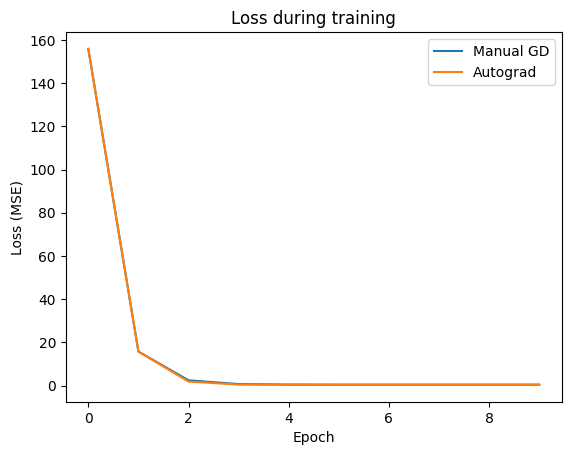

In [94]:
plt.figure()
plt.plot(losses_manual[:10], label="Manual GD")
plt.plot(losses_auto[:10], label="Autograd")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Loss during training")
plt.legend()
plt.show()